# Wakefield: a reentrant cavity (with a field-line animation)

A **reentrant** cell — its equator wall overhanging the iris neck — trades a higher gradient for a stronger wake. We run the ABCI wakefield on the reentrant TESLA cell of

> V. Shemelin, H. Padamsee, R. L. Geng, *Optimal cells for TESLA accelerating structure*, Nucl. Instrum. Methods A **496** (2003) 1-7,

their most reentrant cell (Table 2, `delta_e = +50%`, aperture `Ra = 35 mm`), and also **animate the electric field lines** as the bunch passes.

> Needs the bundled `ABCI.exe` (Windows) / `abci` on PATH; ABCI needs a beam pipe at **both** ends.

In [1]:
import os, tempfile
import numpy as np
import matplotlib.pyplot as plt
from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style
apply_style()

c0 = 299_792_458.0
L = c0 / 1.3e9 / 4 * 1e3        # lambda/4 at 1.3 GHz, in mm
# [A, B, a, b, Ri, L, Req] (mm) - Shemelin et al. Table 2, delta_e = +50%, Ra = 35 mm
cell = [56.56, 37.12, 6.50, 7.34, 35.0, L, 97.76]

## The reentrant shape

The mirrored section shows the overhanging equator.

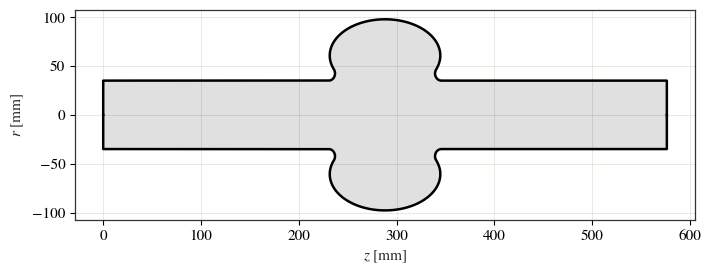

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
cav = EllipticalCavity(1, cell, cell, cell, beampipe='both', name='reentrant')
cav.set_workspace(os.path.join(tempfile.mkdtemp(), 'reentrant_wf'))
cav.plot('geometry', mirror=True)

## Run the solve

`save_fields=True` additionally turns on ABCI's electric-field-line output, so the field snapshots are written alongside the wake and impedance.

In [3]:
cav.wakefield.run({'MROT': 2, 'wakelength': 20, 'bunch_length': 25, 'save_fields': True})
cav.wakefield.qois

{'|k_loss| [V/pC]': 0.2242,
 'k_FM [V/pC]': 0.16927,
 'k_loss_HOM [V/pC]': 0.05493000000000001,
 '|k_kick| [V/pC/m]': 6.822}

## Impedance and wake

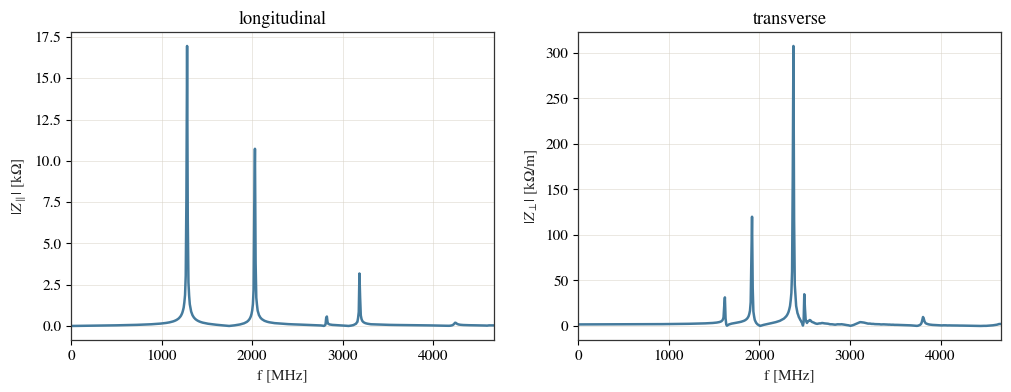

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
cav.wakefield.plot_impedance('longitudinal', ax=a1, show=False)
cav.wakefield.plot_impedance('transverse', ax=a2, show=False)
a1.set_title('longitudinal'); a2.set_title('transverse'); plt.show()

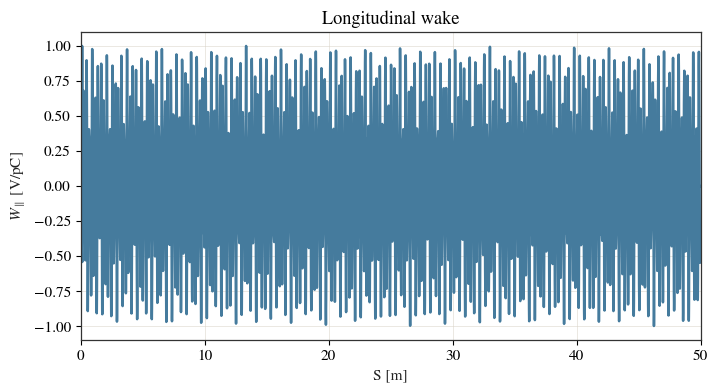

<Axes: title={'center': 'Longitudinal wake'}, xlabel='S [m]', ylabel='$W_\\parallel$ [V/pC]'>

In [5]:
cav.wakefield.plot_wake('longitudinal')

## The electric field lines

`animate_fields()` plays ABCI's field-line snapshots (the inline player is a compact H.264 video, so the whole sequence embeds). Reentrant noses concentrate the field.

In [6]:
cav.wakefield.animate_fields()

Encoding inline video:   0%|          | 0/5 [00:00<?, ?frame/s]

## Where to go next

- [Wakefield: a spline cavity](spline.ipynb) · [an RF gun](rfgun.ipynb) · [varying a parameter](parameter_sweep.ipynb).
- [Multipacting: a reentrant cavity](../multipacting/reentrant.ipynb) — the same cell.